In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Cleaning**

In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df=df.drop('Cabin',axis=1)

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# **Analysis**


In [10]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
df['Survived'].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

## **do males and females have different survival rates?**

In [14]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## **did rich people survived more than poor people?**

In [15]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

### 1 = rich
### 2 = middle
### 3 = poor
## **we can see rich survived more**  
### reasons: they were on upperdecks
### closure to lifeboats
### got more priority during rescue
             

#### MULTI-VARIABLE ANALYSIS

In [17]:
df.groupby(['Sex','Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

**does traveling with family affect survival?**

In [19]:
df['FamilySize']=df['SibSp']+df['Parch']

In [20]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

In [21]:
df['IsAlone']=(df['FamilySize']==0)

In [22]:
df.groupby('IsAlone')['Survived'].mean()

IsAlone
False    0.505650
True     0.303538
Name: Survived, dtype: float64

# **Visualization**

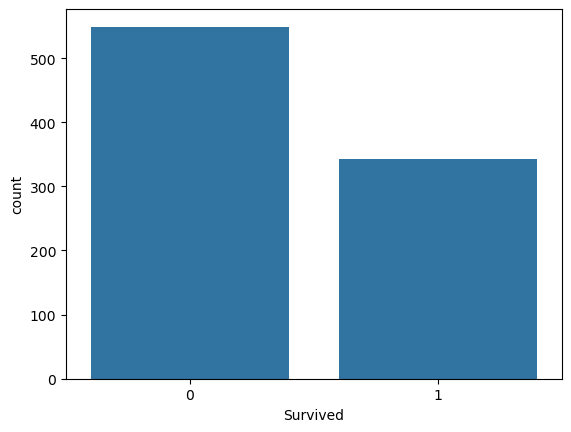

In [23]:
sns.countplot(x='Survived', data=df)
plt.show()

### survival by gender

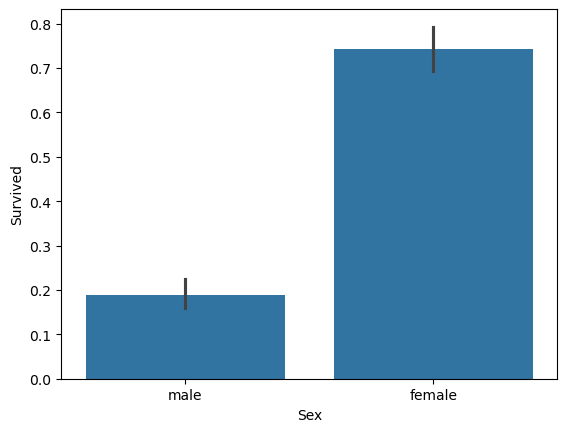

In [24]:
sns.barplot(x='Sex',y='Survived',data=df)
plt.show()

### survival by class

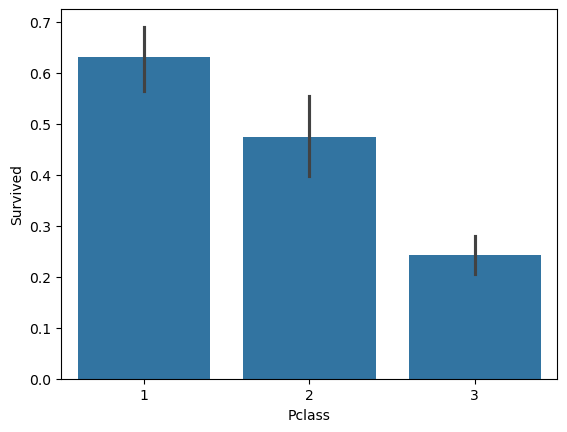

In [25]:
sns.barplot(x='Pclass',y='Survived',data=df)
plt.show()

### age distribution

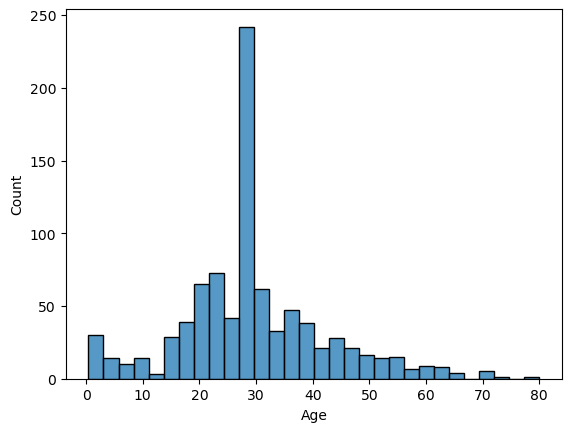

In [26]:
sns.histplot(df['Age'],bins=30)
plt.show()

### correlation heatmap

In [29]:
df['Sex']=df['Sex'].map({'male':0,'female':1})

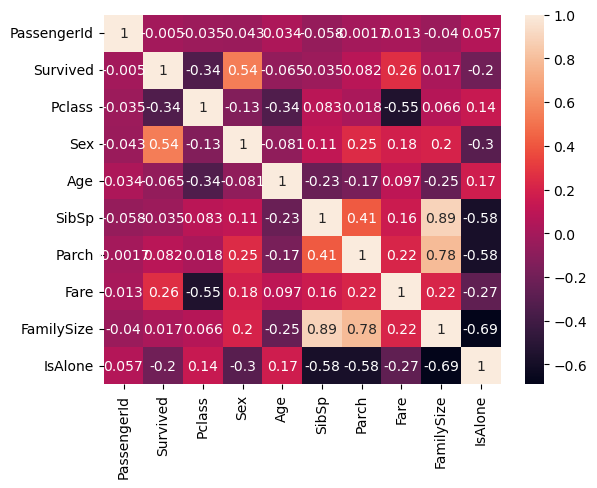

In [30]:

sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

### insights
->Gender is the most important factor affecting survival.
->Female had significantly higher survival rates than males.
->Higher class passengers(Pclass1) survived more.
->Passengers who had paid higher fares had better survival chances.
->People traveling with family had higher survival than those alone.  

In [31]:
df.to_csv("cleaned_titanic.csv", index=False)